In [4]:
import os
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
path = os.path.abspath(os.getcwd())
file_path = os.path.join(os.path.dirname(path), "data", "rent_prediction.csv")

df = pd.read_csv(file_path)

### Dimensions, colonnes et types

In [55]:
numeric_cols = list(df.drop("IdentifiantMaison", axis=1).select_dtypes(include=["number"]).columns)
category_cols = list(df.drop("IdentifiantMaison", axis=1).select_dtypes(include=["object", "str"]).columns)

print(f"Colonnes dans les données : {list(df.columns)}")
print()
print(f"La forme de données du DataSet : {df.shape}")
print()
print(f"Type de données du DataSet : {df.info()}")

Colonnes dans les données : ['IdentifiantMaison', 'Chambres', 'Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin', 'Superficie_m2', 'DistanceRoute_m', 'Quartier', 'AgeMaison', 'LoyerMensuel_BIF']

La forme de données du DataSet : (510, 12)

<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IdentifiantMaison      510 non-null    int64  
 1   Chambres               485 non-null    float64
 2   Salon                  485 non-null    str    
 3   SalleDeBainInterieure  485 non-null    str    
 4   Parking                485 non-null    str    
 5   Meuble                 485 non-null    str    
 6   Jardin                 485 non-null    str    
 7   Superficie_m2          485 non-null    float64
 8   DistanceRoute_m        485 non-null    float64
 9   Quartier               485 non-null    str    
 10  AgeMaison              4

### Premier coup d'oeil aux données

In [6]:
df.head()
df.tail()
df.sample(10)

,IdentifiantMaison,Chambres,Salon,SalleDeBainInterieure,Parking,Meuble,Jardin,Superficie_m2,DistanceRoute_m,Quartier,AgeMaison,LoyerMensuel_BIF
444,445,4.0,Oui,Non,Non,Non,Oui,179.0,92.0,Cibitoke,8.0,944078
163,164,6.0,Oui,Oui,Non,Non,Non,267.0,209.0,Gihosha,32.0,2036681
252,253,4.0,Oui,Oui,Non,Non,Oui,216.0,196.0,Kinama,34.0,728007
488,489,5.0,Oui,Oui,NaN,Non,Oui,225.0,142.0,Rohero,9.0,2600000
404,405,5.0,Oui,Oui,Oui,Non,Oui,241.0,213.0,Gasekebuye,3.0,2504289
351,352,4.0,Oui,Oui,Oui,Non,Oui,190.0,260.0,Nyakabiga,7.0,1377223
306,307,6.0,Oui,Oui,Non,Non,Non,284.0,32.0,Rohero,NaN,2600000
279,280,6.0,Oui,Oui,Non,Non,Non,257.0,142.0,NaN,20.0,1048698
112,113,3.0,NaN,NaN,Oui,Non,Non,134.0,218.0,Nyakabiga,0.0,719344
41,42,3.0,Oui,Non,NaN,Non,Oui,151.0,191.0,Gihosha,26.0,1609464


### Statistiques descriptives

In [14]:
df.describe()
# df.describe(include=["object"])

,house_id,rooms,Superficie_m2,house_age,monthly_rent
count,510.000000,485.000000,485.000000,4.850000e+02,5.090000e+02
mean,255.500000,3.521649,168.762887,5.380724e+03,1.241945e+06
std,147.368586,1.707436,79.610256,1.180590e+05,6.985334e+05
min,1.000000,1.000000,30.000000,0.000000e+00,1.361490e+05
25%,128.250000,2.000000,103.000000,1.000000e+01,6.991380e+05
50%,255.500000,4.000000,171.000000,2.000000e+01,1.077747e+06
75%,382.750000,5.000000,236.000000,3.000000e+01,1.678140e+06
max,510.000000,6.000000,320.000000,2.600000e+06,2.600000e+06


### Identification de valeurs maquantes

In [15]:
df.isnull()
df.isnull().sum().sort_values(ascending=False)

rooms              25
living_room        25
indoor_bathroom    25
Meuble             25
Jardin             25
Superficie_m2      25
dstance_to_road    25
Quartier           25
house_age          25
parking            24
monthly_rent        1
house_id            0
dtype: int64

### Lignes en double

In [17]:
df.duplicated()
df.duplicated().sum()

0      False
1      False
2      False
3      False
4      False
       ...  
505    False
506    False
507    False
508    False
509    False
Length: 510, dtype: bool

### Analyse de la cible

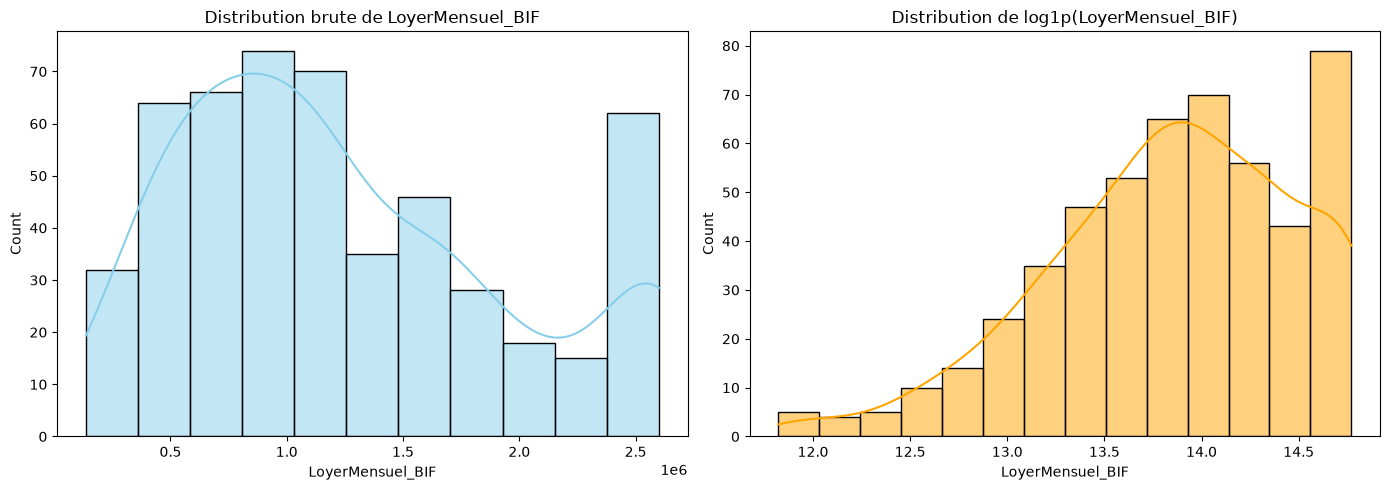

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["LoyerMensuel_BIF"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution brute de LoyerMensuel_BIF")

# Distribution avec Transformation Log
sns.histplot(np.log1p(df["LoyerMensuel_BIF"]), kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution de log1p(LoyerMensuel_BIF)")

plt.tight_layout()
plt.show()

### Analyses de features numériques

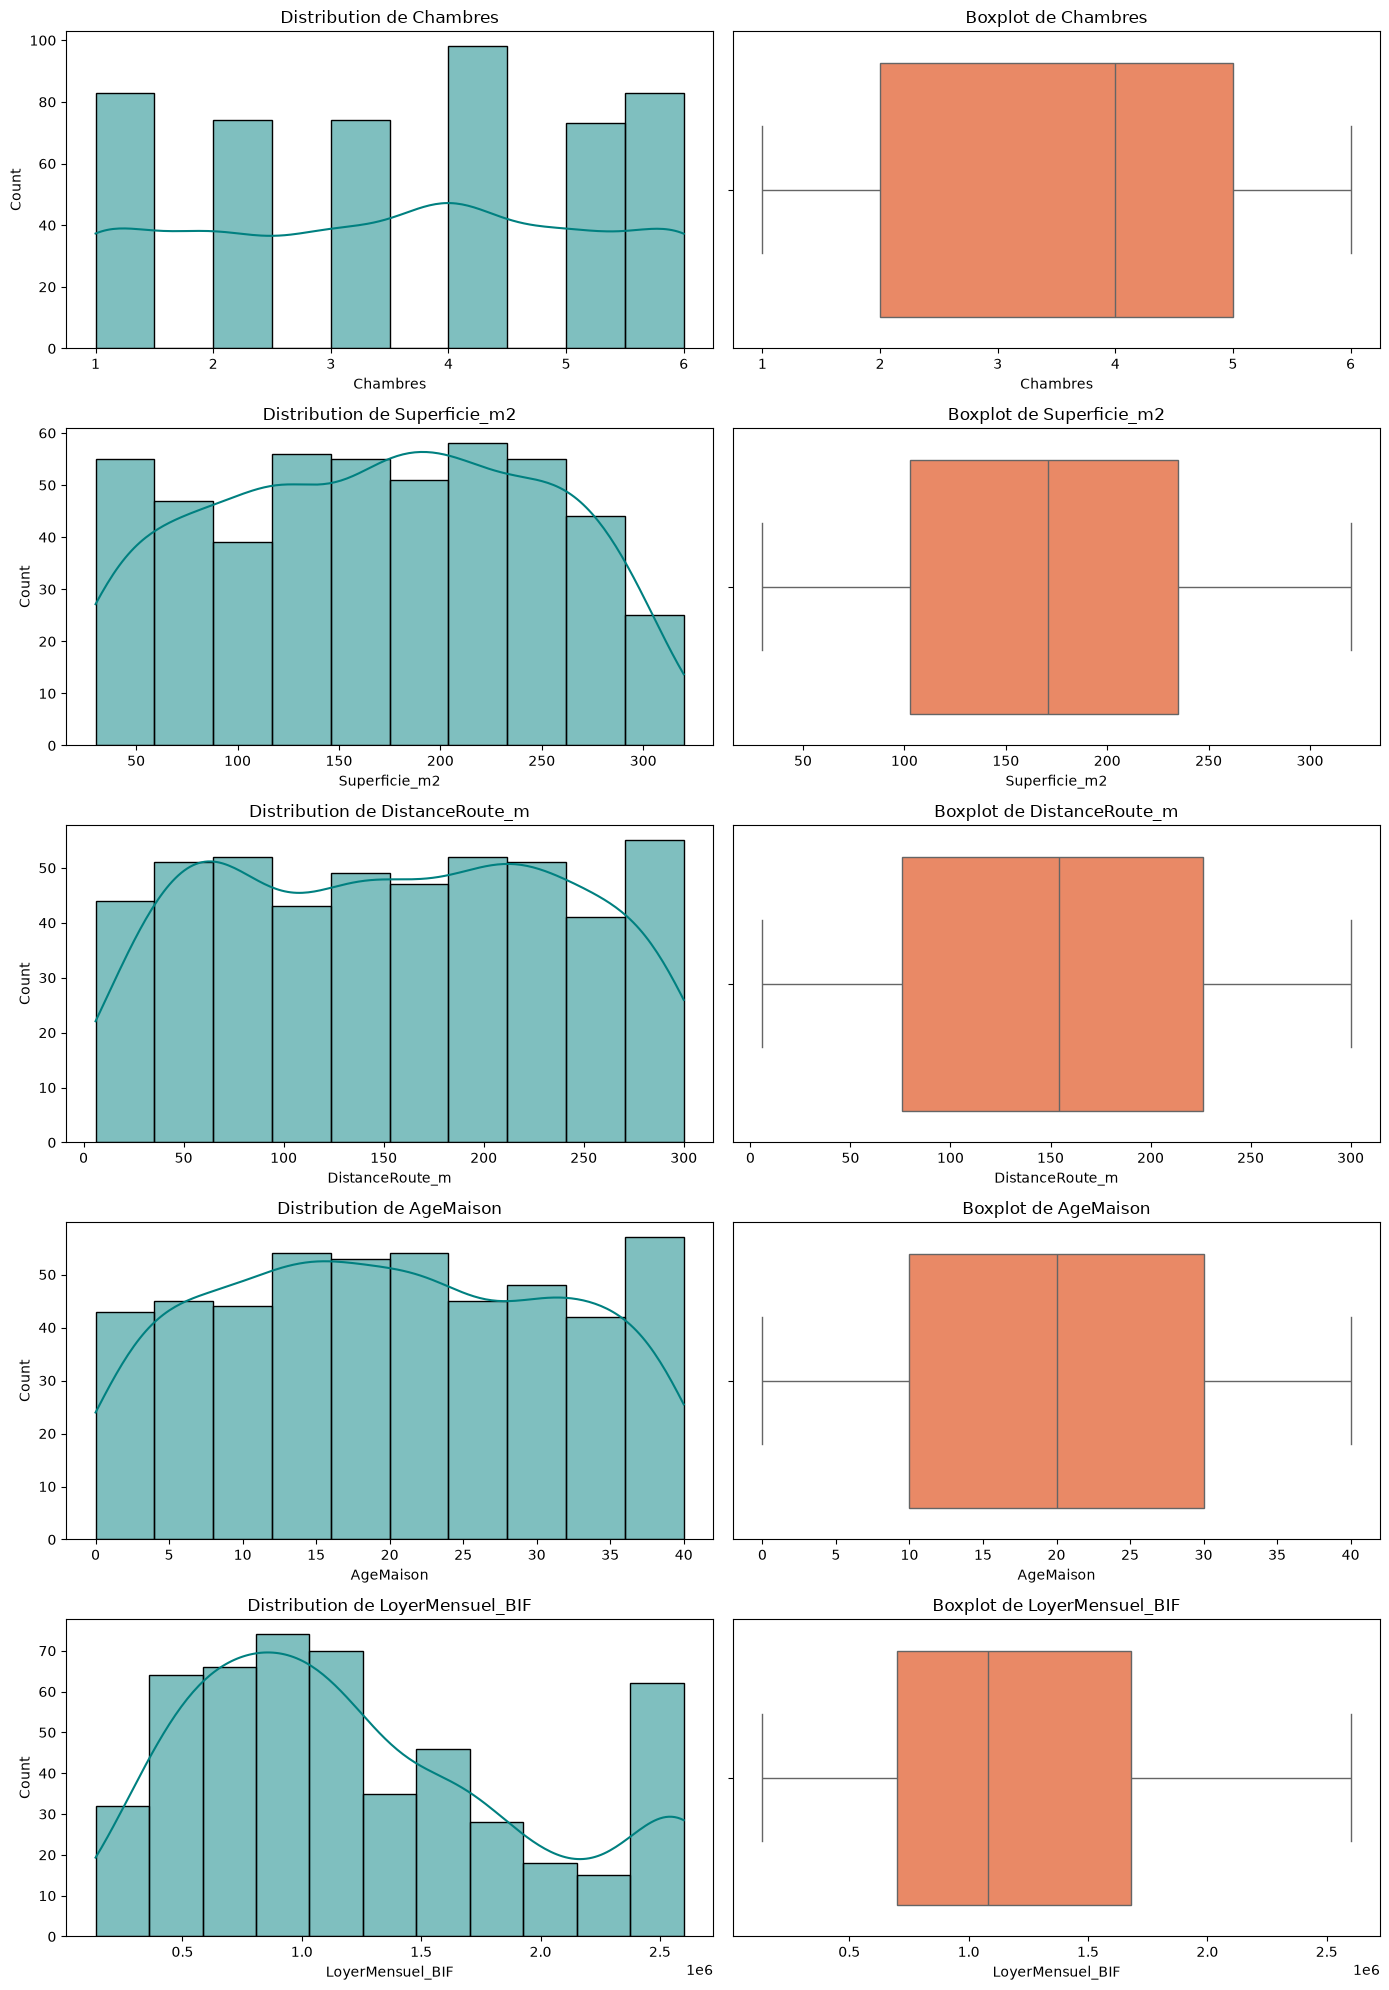

In [29]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="teal")
    axes[i, 0].set_title(f"Distribution de {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="coral")
    axes[i, 1].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

### Analyses de variables catégorielles

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(category_cols):
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        ax=axes[i],
        palette="Set2",
        order=df[col].value_counts().index,
    )
    axes[i].set_title(f"Répartition de {col} (Cardinalité: {df[col].nunique()})")
    axes[i].tick_params(axis="x", rotation=45 if df[col].nunique() > 5 else 0)

plt.tight_layout()
plt.show()

### Pattern des valeurs maquantes

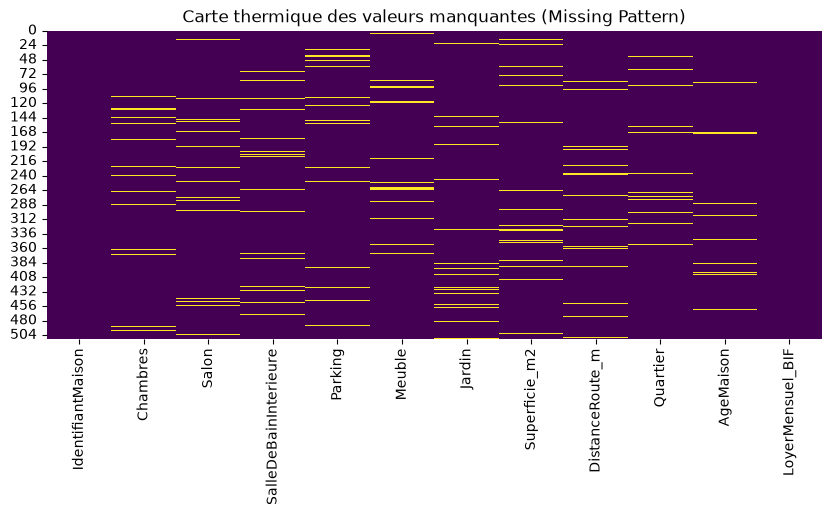

In [56]:
# Visualiser si les manques sont corrélés entre eux (MCAR vs MNAR)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Carte thermique des valeurs manquantes (Missing Pattern)")
plt.show()

### Corrélation avec la variable cible (LoyerMensuel_BIF)

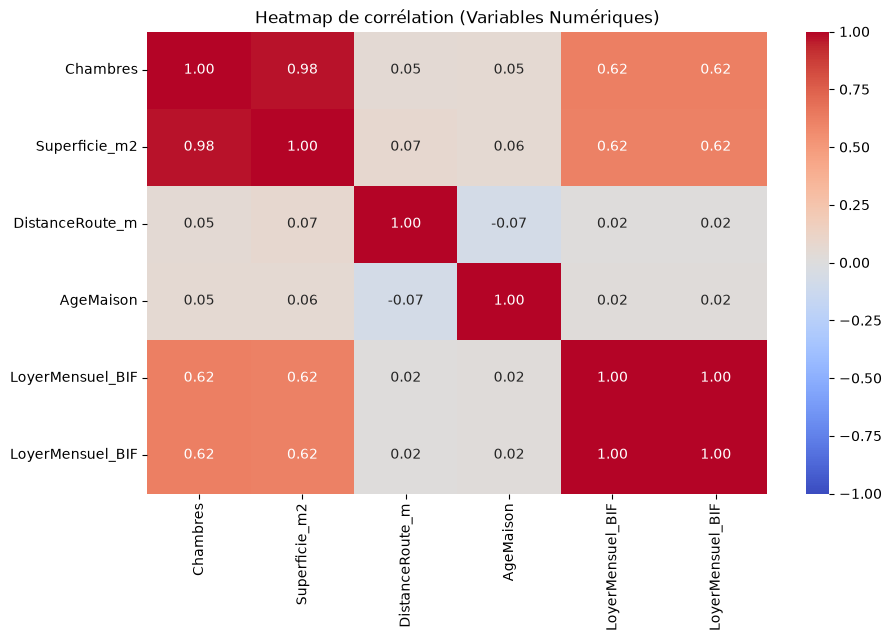

In [35]:
plt.figure(figsize=(1, 6))

corr_matrix = df[numeric_cols + ["LoyerMensuel_BIF"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Heatmap de corrélation (Variables Numériques)")
plt.show()

### Scatter plots / Boxplots croisant chaque feature avec LoyerMensuel_BIF.

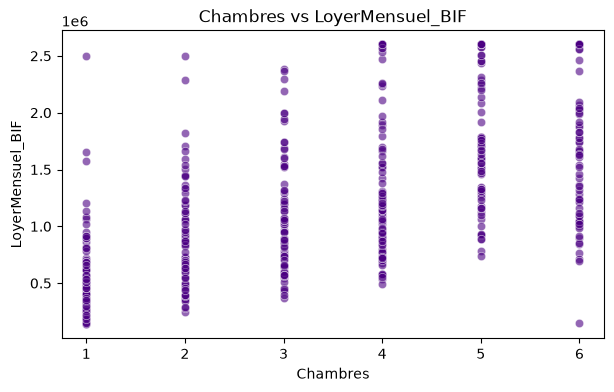

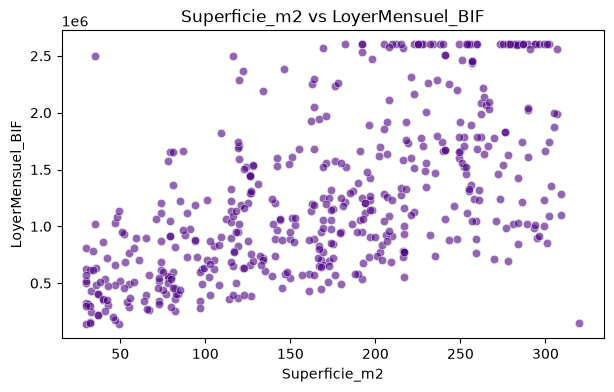

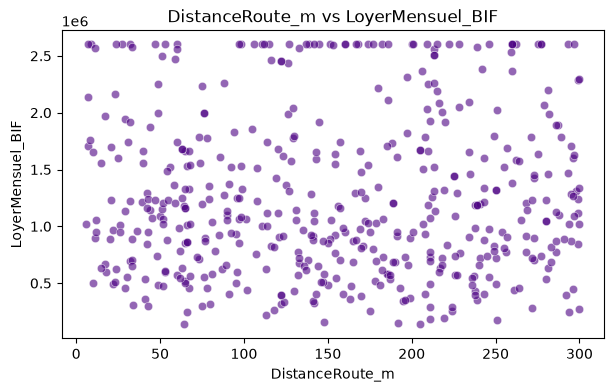

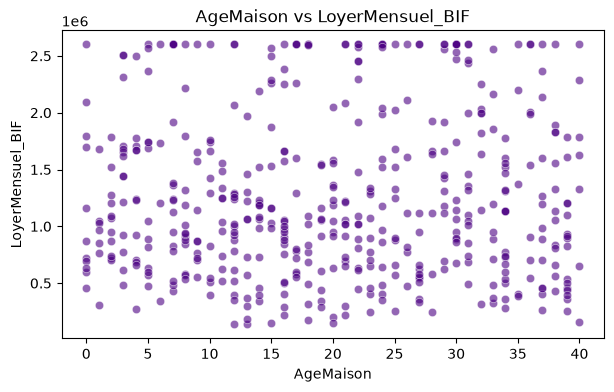

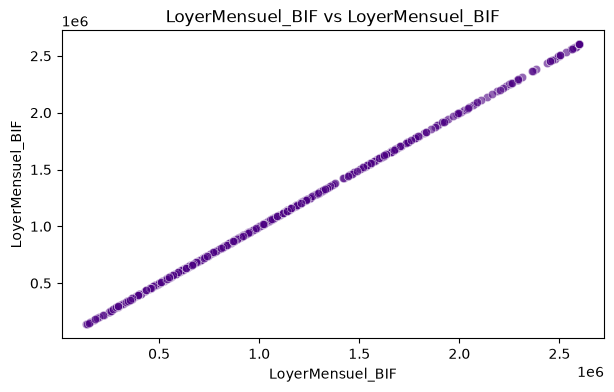

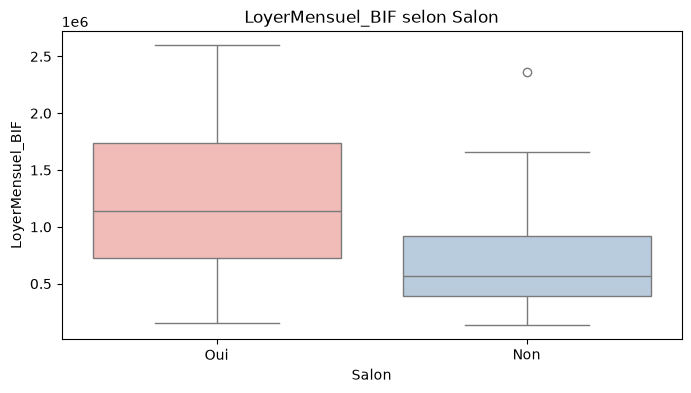

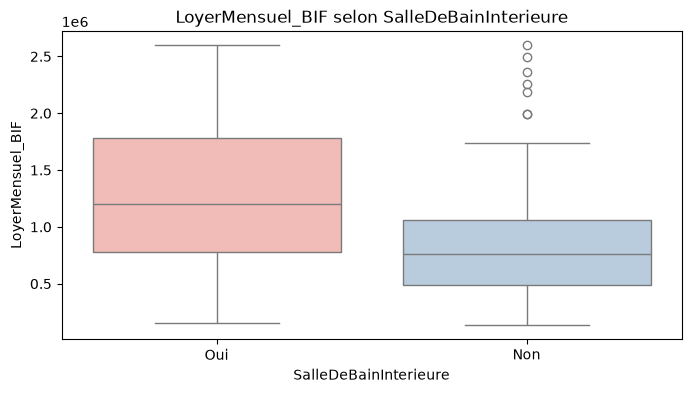

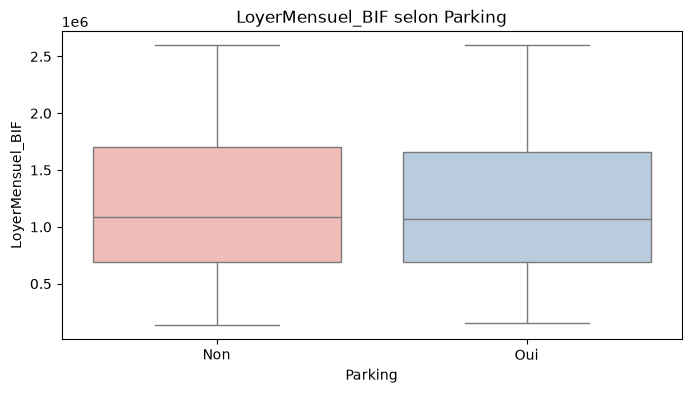

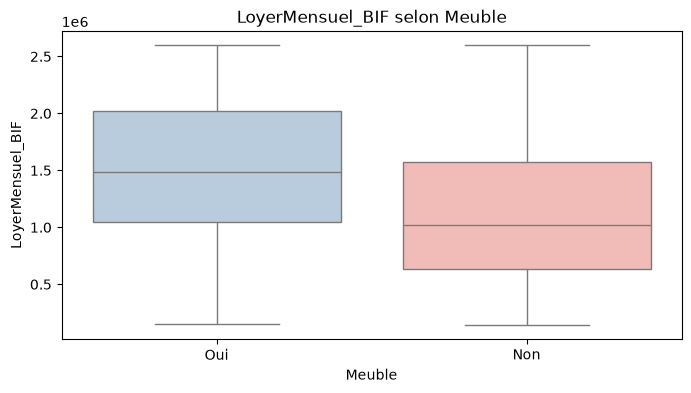

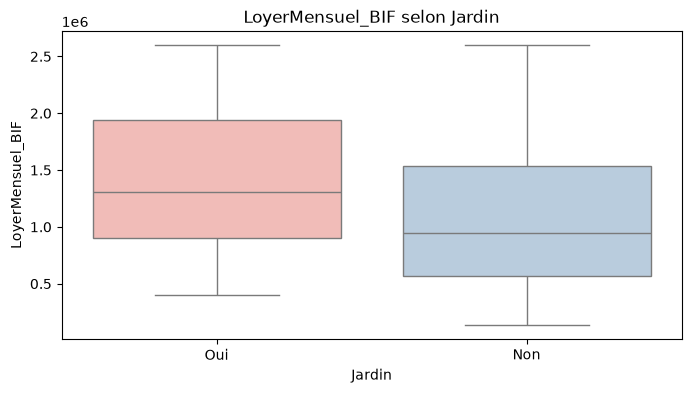

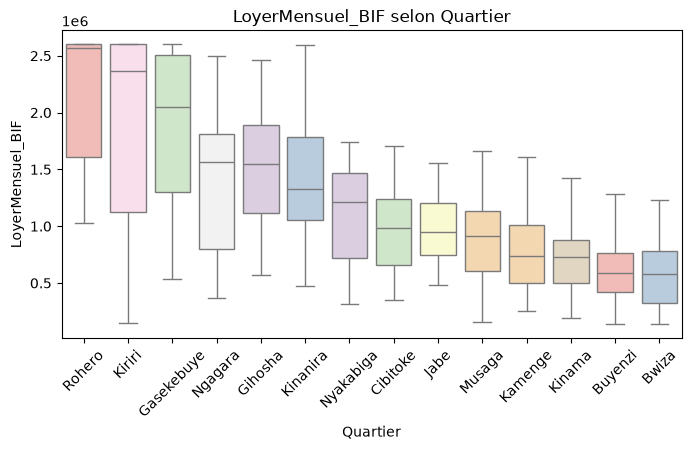

In [59]:
# Scatter plots pour les variables numériques
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(
        data=df, x=col, y="LoyerMensuel_BIF", alpha=0.6, color="indigo"
    )
    plt.title(f"{col} vs LoyerMensuel_BIF")
    plt.show()

# Boxplots pour les variables catégorielles
for col in category_cols:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        y="LoyerMensuel_BIF",
        palette="Pastel1",
        order=df.groupby(col)["LoyerMensuel_BIF"]
        .median()
        .sort_values(ascending=False)
        .index,
    )
    
    plt.title(f"LoyerMensuel_BIF selon {col}")
    plt.xticks(rotation=45 if df[col].nunique() > 5 else 0)
    plt.show()

In [2]:
import pandas as pd

eda_decisions_data = {
    "Variable / Aspect": [
        "Lignes Manquantes (Global)",
        "AgeMaison",
        "LoyerMensuel_BIF (Variable Cible)",
        "Chambres & Superficie_m2",
        "Quartier",
        "Équipements (Meuble, Jardin, Salon, SdB)",
        "DistanceRoute_m",
        "Parking",
    ],
    "Données Observées (EDA)": [
        "25 lignes totalement vides sur l'ensemble des features (485 non-nulls sur 510)[cite: 1].",
        "Valeur maximale aberrante à 2 600 000 ans (fuite possible de la valeur du loyer)[cite: 1].",
        "Distribution asymétrique à droite + effet de plafonnement/seuil marqué à 2 600 000 BIF[cite: 1].",
        "Corrélation quasi-parfaite de 0.98 entre les deux variables + corrélation de 0.62 avec le loyer[cite: 1].",
        "Forte hiérarchie des prix : Rohero/Kiriri très élevés vs Buyenzi/Bwiza très bas[cite: 1].",
        "Impact positif net sur le loyer médian (notamment le caractère Meublé)[cite: 1].",
        "Très faible corrélation linéaire avec le loyer (~0.02)[cite: 1].",
        "Faible différenciation sur la distribution des loyers entre Oui et Non[cite: 1].",
    ],
    "Action / Décision Technique": [
        "Suppression directe des 25 lignes concernées.",
        "Remplacement des valeurs > 100 par NaN puis imputation par la médiane selon le Quartier.",
        "Passage de la cible au log (log1p) pour lisser l'asymétrie + test d'un modèle adapté aux données censurées.",
        "Conservation de Superficie_m2 pour modèles linéaires (ou création du ratio Superficie/Chambre) ; conservation des deux pour arbres/XGBoost.",
        "Application d'un Target Encoding (ou Ordinal Encoding basé sur le loyer médian).",
        "Création d'une feature composite 'Standing_Score' (somme des équipements présents).",
        "Conservation temporaire ; test d'une binarisation (ex: Proche < 200m vs Éloigné) ou sélection par Ridge/Lasso.",
        "Simplification ou faible pondération lors du Feature Engineering.",
    ],
    "Justification Technique": [
        "Les données manquent simultanément sur tout le profil (MCAR/MAR), la suppression évite d'injecter du bruit sans perte d'information utile.",
        "Corrige une erreur manifeste de saisie tout en préservant la cohérence géographique globale.",
        "Rapproche la cible d'une distribution normale, ce qui stabilise la variance et améliore les performances des régresseurs.",
        "Évite le problème de multicolinéarité sévère qui déstabilise les coefficients des modèles linéaires.",
        "Conserve l'information spatiale et la valeur foncière sans exploser le nombre de dimensions (contrairement au One-Hot Encoding).",
        "Synthétise le niveau de confort général du bien en une seule variable explicative puissante.",
        "Transforme une variable continue peu explicative en un seuil de proximité plus pertinent.",
        "Évite de surcharger les modèles avec des variables peu discriminantes.",
    ],
}

# Création du DataFrame
eda_decisions = pd.DataFrame(eda_decisions_data)

pd.set_option("display.max_colwidth", None)
eda_decisions

,Variable / Aspect,Données Observées (EDA),Action / Décision Technique,Justification Technique
0,Lignes Manquantes (Global),25 lignes totalement vides sur l'ensemble des features (485 non-nulls sur 510)[cite: 1].,Suppression directe des 25 lignes concernées.,"Les données manquent simultanément sur tout le profil (MCAR/MAR), la suppression évite d'injecter du bruit sans perte d'information utile."
1,AgeMaison,Valeur maximale aberrante à 2 600 000 ans (fuite possible de la valeur du loyer)[cite: 1].,Remplacement des valeurs > 100 par NaN puis imputation par la médiane selon le Quartier.,Corrige une erreur manifeste de saisie tout en préservant la cohérence géographique globale.
2,LoyerMensuel_BIF (Variable Cible),Distribution asymétrique à droite + effet de plafonnement/seuil marqué à 2 600 000 BIF[cite: 1].,Passage de la cible au log (log1p) pour lisser l'asymétrie + test d'un modèle adapté aux données censurées.,"Rapproche la cible d'une distribution normale, ce qui stabilise la variance et améliore les performances des régresseurs."
3,Chambres & Superficie_m2,Corrélation quasi-parfaite de 0.98 entre les deux variables + corrélation de 0.62 avec le loyer[cite: 1].,Conservation de Superficie_m2 pour modèles linéaires (ou création du ratio Superficie/Chambre) ; conservation des deux pour arbres/XGBoost.,Évite le problème de multicolinéarité sévère qui déstabilise les coefficients des modèles linéaires.
4,Quartier,Forte hiérarchie des prix : Rohero/Kiriri très élevés vs Buyenzi/Bwiza très bas[cite: 1].,Application d'un Target Encoding (ou Ordinal Encoding basé sur le loyer médian).,Conserve l'information spatiale et la valeur foncière sans exploser le nombre de dimensions (contrairement au One-Hot Encoding).
5,"Équipements (Meuble, Jardin, Salon, SdB)",Impact positif net sur le loyer médian (notamment le caractère Meublé)[cite: 1].,Création d'une feature composite 'Standing_Score' (somme des équipements présents).,Synthétise le niveau de confort général du bien en une seule variable explicative puissante.
6,DistanceRoute_m,Très faible corrélation linéaire avec le loyer (~0.02)[cite: 1].,Conservation temporaire ; test d'une binarisation (ex: Proche < 200m vs Éloigné) ou sélection par Ridge/Lasso.,Transforme une variable continue peu explicative en un seuil de proximité plus pertinent.
7,Parking,Faible différenciation sur la distribution des loyers entre Oui et Non[cite: 1].,Simplification ou faible pondération lors du Feature Engineering.,Évite de surcharger les modèles avec des variables peu discriminantes.
